# Análisis de RIBs recolectadas (previo al entrenamiento)

Este notebook permite inspeccionar rápidamente la calidad de los datos construidos desde RIBs (archivos de nodos y aristas) antes del entrenamiento del GNN.

Incluye:
- Resumen general de nodos/aristas
- Distribución de clases de relación
- Validaciones de calidad (duplicados, self-loops, IDs faltantes)
- Chequeo de consistencia por pares no dirigidos

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

print("Notebook de análisis cargado correctamente.")

Notebook de análisis cargado correctamente.


## 1) Configuración de rutas

Ajusta `data_path` si tus CSV están en otra carpeta.

In [2]:
data_path = Path("/media/vale/KINGSTON/TESIS/data_2026")

nodes_file = data_path / "nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv"
edges_file = data_path / "edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv"

print(f"data_path: {data_path}")
print(f"nodes_file existe: {nodes_file.exists()} -> {nodes_file}")
print(f"edges_file existe: {edges_file.exists()} -> {edges_file}")

if not nodes_file.exists() or not edges_file.exists():
    print("\n[AVISO] No se encontraron los archivos esperados.")
    print("Puedes editar esta celda para apuntar a los CSV correctos.")

data_path: /media/vale/KINGSTON/TESIS/data_2026
nodes_file existe: True -> /media/vale/KINGSTON/TESIS/data_2026/nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv
edges_file existe: True -> /media/vale/KINGSTON/TESIS/data_2026/edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv


## 2) Carga de datos

Si las rutas son correctas, esta celda carga nodos y aristas.

In [3]:
if nodes_file.exists() and edges_file.exists():
    df_nodes = pd.read_csv(nodes_file)
    df_edges = pd.read_csv(edges_file)

    print("Carga OK")
    print(f"- df_nodes: {df_nodes.shape}")
    print(f"- df_edges: {df_edges.shape}")
else:
    df_nodes = None
    df_edges = None
    print("No se cargaron datos (revisar rutas).")

Carga OK
- df_nodes: (79504, 71)
- df_edges: (734381, 6)


## 3) Resumen general

Métricas básicas para validar volumen y cobertura.

In [4]:
if df_nodes is not None and df_edges is not None:
    print("=== Resumen general ===")
    print(f"Nodos totales: {len(df_nodes):,}")
    print(f"Aristas totales: {len(df_edges):,}")

    if "asn" in df_nodes.columns:
        print(f"ASNs únicos: {df_nodes['asn'].nunique():,}")

    if "node_id" in df_nodes.columns:
        print(f"node_id únicos: {df_nodes['node_id'].nunique():,}")

    rel_col = next((c for c in ["label", "relationship", "Relationship"] if c in df_edges.columns), None)
    if rel_col:
        print(f"\nColumna de relación detectada: {rel_col}")
        print(df_edges[rel_col].value_counts(dropna=False).sort_index())
else:
    print("Sin datos cargados.")

=== Resumen general ===
Nodos totales: 79,504
Aristas totales: 734,381
ASNs únicos: 79,504
node_id únicos: 79,504

Columna de relación detectada: relationship
relationship
-1     73943
 0    340512
 1    159963
 2    159963
Name: count, dtype: int64


## 4) Chequeos de calidad de aristas

Valida problemas típicos: duplicados, self-loops, IDs inexistentes, nulos.

In [5]:
if df_nodes is not None and df_edges is not None:
    required_edge_cols = {"src_id", "dst_id"}
    if not required_edge_cols.issubset(df_edges.columns):
        print(f"Faltan columnas requeridas en edges: {required_edge_cols - set(df_edges.columns)}")
    else:
        print("=== Calidad de aristas ===")

        n_null_src = df_edges['src_id'].isna().sum()
        n_null_dst = df_edges['dst_id'].isna().sum()
        print(f"Nulos src_id: {n_null_src:,}")
        print(f"Nulos dst_id: {n_null_dst:,}")

        dup_directed = df_edges.duplicated(subset=['src_id', 'dst_id']).sum()
        print(f"Duplicados dirigidos (src_id,dst_id): {dup_directed:,}")

        self_loops = (df_edges['src_id'] == df_edges['dst_id']).sum()
        print(f"Self-loops (src_id == dst_id): {self_loops:,}")

        if 'node_id' in df_nodes.columns:
            valid_nodes = set(df_nodes['node_id'].dropna().astype(int).tolist())
            src_missing = (~df_edges['src_id'].astype('Int64').isin(valid_nodes)).sum()
            dst_missing = (~df_edges['dst_id'].astype('Int64').isin(valid_nodes)).sum()
            print(f"src_id no encontrados en nodes: {src_missing:,}")
            print(f"dst_id no encontrados en nodes: {dst_missing:,}")
else:
    print("Sin datos cargados.")

=== Calidad de aristas ===
Nulos src_id: 0
Nulos dst_id: 0
Duplicados dirigidos (src_id,dst_id): 0
Self-loops (src_id == dst_id): 0
src_id no encontrados en nodes: 0
dst_id no encontrados en nodes: 0


## 5) Distribución de clases de relación

Visualiza el desbalance de clases antes del split de entrenamiento.

Relationship column detected: relationship


,Class,Count,Percentage (%)
0,-1,73943,10.07
1,0,340512,46.37
2,1,159963,21.78
3,2,159963,21.78


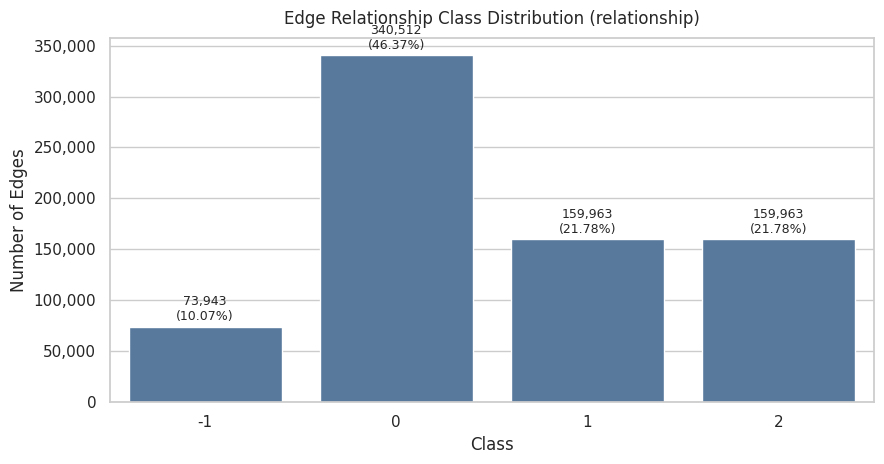

In [6]:
if df_edges is not None:
    import matplotlib.ticker as mtick

    rel_col = next((c for c in ["label", "relationship", "Relationship"] if c in df_edges.columns), None)

    if rel_col is None:
        print("No relationship column found in edges data.")
    else:
        dist = df_edges[rel_col].value_counts(dropna=False).sort_index()
        total = dist.sum()
        pct = (dist / total * 100).round(2)

        summary = pd.DataFrame({
            "Class": dist.index.astype(str),
            "Count": dist.values,
            "Percentage (%)": pct.values,
        })

        print(f"Relationship column detected: {rel_col}")
        display(summary)

        plt.figure(figsize=(9, 4.8))
        ax = sns.barplot(data=summary, x="Class", y="Count", color="#4C78A8")

        ax.set_title(f"Edge Relationship Class Distribution ({rel_col})", fontsize=12, pad=10)
        ax.set_xlabel("Class")
        ax.set_ylabel("Number of Edges")
        ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

        ymax = summary["Count"].max() if not summary.empty else 0
        offset = max(1, int(ymax * 0.01))

        for i, row in summary.iterrows():
            label = f"{int(row['Count']):,}\n({row['Percentage (%)']:.2f}%)"
            ax.text(i, row["Count"] + offset, label, ha="center", va="bottom", fontsize=9)

        plt.tight_layout()
        plt.show()
else:
    print("No data loaded.")

## 6) Consistencia por pares no dirigidos

Analiza cuántos pares aparecen en una sola dirección vs ambas direcciones.

In [7]:
if df_edges is not None and {'src_id', 'dst_id'}.issubset(df_edges.columns):
    pairs = pd.DataFrame({
        'u': np.minimum(df_edges['src_id'].values, df_edges['dst_id'].values),
        'v': np.maximum(df_edges['src_id'].values, df_edges['dst_id'].values),
    })

    pair_counts = pairs.value_counts().rename('num_dir').reset_index()
    one_dir = (pair_counts['num_dir'] == 1).sum()
    two_or_more = (pair_counts['num_dir'] >= 2).sum()

    print("=== Consistencia por par no dirigido ===")
    print(f"Pares totales: {len(pair_counts):,}")
    print(f"Solo una dirección: {one_dir:,}")
    print(f"Ambas direcciones (o más): {two_or_more:,}")

    rel_col = next((c for c in ["label", "relationship", "Relationship"] if c in df_edges.columns), None)
    if rel_col is not None:
        tmp = df_edges[['src_id', 'dst_id', rel_col]].copy()
        tmp['u'] = np.minimum(tmp['src_id'].values, tmp['dst_id'].values)
        tmp['v'] = np.maximum(tmp['src_id'].values, tmp['dst_id'].values)

        sig = (
            tmp.groupby(['u', 'v'])[rel_col]
            .apply(lambda x: tuple(sorted(x.tolist())))
            .value_counts()
            .head(10)
        )
        print("\nTop-10 firmas de etiquetas por par (u,v):")
        display(sig.to_frame('pares'))
else:
    print("Sin datos cargados o faltan src_id/dst_id.")

=== Consistencia por par no dirigido ===
Pares totales: 403,748
Solo una dirección: 73,115
Ambas direcciones (o más): 330,633

Top-10 firmas de etiquetas por par (u,v):


,pares
relationship,
"(0, 0)",170256
"(1, 2)",159963
"(-1,)",73115
"(-1, -1)",414


## 9) Reciprocidad, simetría P2C↔C2P y conectividad del grafo

- **Reciprocidad**: fracción de aristas `(u→v)` para las que también existe `(v→u)`. Alta reciprocidad implica que el GNN recibirá mensajes en ambas direcciones entre los mismos pares.
- **Simetría P2C↔C2P**: por construcción, cada arista P2C debe tener su inverso C2P. Verificar esto valida la integridad del dataset.
- **Densidad**: con ~80k nodos y ~730k aristas el grafo es extremadamente disperso, lo que es típico en redes de internet y afecta la elección de profundidad del GNN (más capas → más señal propagada).

In [8]:
if df_edges is not None:
    print("=== Análisis de reciprocidad ===")
    edge_set = set(zip(df_edges["src_id"].values, df_edges["dst_id"].values))
    n_reciprocal = sum(1 for (u, v) in edge_set if (v, u) in edge_set)
    reciprocity = n_reciprocal / len(edge_set)
    print(f"Aristas dirigidas totales : {len(edge_set):>10,}")
    print(f"Con arista inversa presente: {n_reciprocal:>10,}")
    print(f"Tasa de reciprocidad       : {reciprocity:.4f} ({reciprocity * 100:.2f}%)")

    rel_col = next((c for c in ["label", "relationship", "Relationship"] if c in df_edges.columns), None)
    if rel_col:
        p2c_pairs = set(zip(
            df_edges.loc[df_edges[rel_col] == 1, "src_id"],
            df_edges.loc[df_edges[rel_col] == 1, "dst_id"],
        ))
        c2p_pairs = set(zip(
            df_edges.loc[df_edges[rel_col] == 2, "src_id"],
            df_edges.loc[df_edges[rel_col] == 2, "dst_id"],
        ))
        p2c_with_c2p = sum(1 for (u, v) in p2c_pairs if (v, u) in c2p_pairs)
        print(f"\nVerificación de simetría P2C ↔ C2P:")
        print(f"  Aristas P2C (u→v): {len(p2c_pairs):,}")
        print(f"  Aristas C2P (v→u): {len(c2p_pairs):,}")
        print(f"  P2C con su C2P inverso exacto: {p2c_with_c2p:,} ({p2c_with_c2p / max(len(p2c_pairs), 1) * 100:.1f}%)")

    print("\n=== Conectividad y densidad del grafo ===")
    n_nodes = df_nodes["node_id"].nunique() if df_nodes is not None and "node_id" in df_nodes.columns else None
    n_edges = len(df_edges)

    if n_nodes:
        density = n_edges / (n_nodes * (n_nodes - 1))
        avg_degree = n_edges / n_nodes
        print(f"Nodos totales           : {n_nodes:>10,}")
        print(f"Aristas dirigidas       : {n_edges:>10,}")
        print(f"Densidad del grafo      : {density:.2e}  ({density * 100:.4f}%)")
        print(f"Grado medio (n_edges/N) : {avg_degree:.2f}")
        print(f"Caracterización         : {'grafo disperso (sparse)' if density < 0.001 else 'grafo denso'}")

    # Nodos aislados
    if df_nodes is not None and "node_id" in df_nodes.columns:
        nodes_with_edges = set(df_edges["src_id"].tolist()) | set(df_edges["dst_id"].tolist())
        all_nodes = set(df_nodes["node_id"].tolist())
        isolated = all_nodes - nodes_with_edges
        print(f"\nNodos sin aristas (aislados): {len(isolated):,} ({len(isolated) / len(all_nodes) * 100:.2f}%)")
        if isolated:
            print("  → Estos nodos no aportan señal al GNN durante message passing.")
else:
    print("Sin datos cargados.")

=== Análisis de reciprocidad ===
Aristas dirigidas totales :    734,381
Con arista inversa presente:    661,266
Tasa de reciprocidad       : 0.9004 (90.04%)

Verificación de simetría P2C ↔ C2P:
  Aristas P2C (u→v): 159,963
  Aristas C2P (v→u): 159,963
  P2C con su C2P inverso exacto: 159,963 (100.0%)

=== Conectividad y densidad del grafo ===
Nodos totales           :     79,504
Aristas dirigidas       :    734,381
Densidad del grafo      : 1.16e-04  (0.0116%)
Grado medio (n_edges/N) : 9.24
Caracterización         : grafo disperso (sparse)

Nodos sin aristas (aislados): 0 (0.00%)


## 10) Perfil de nodos por tipo de relación y matriz de mezcla

Dos análisis clave para entender la estructura local del grafo:

1. **Distribución de grado por tipo de relación**: ¿Los nodos extremo de aristas P2P tienen mayor grado que los de P2C/C2P? Esto es relevante porque los grandes operadores suelen tener muchos peerings P2P.
2. **Mixing matrix**: Analiza con qué tipo de nodo (según su relación dominante de entrada) se conectan los nodos de cada tipo de arista. Un alto valor en la diagonal indica **homofilia** — patrón que el GNN puede aprender directamente.

=== Distribución de grado total por tipo de relación (nodos extremo) ===


,count,mean,std,min,25%,50%,75%,max
relationship,,,,,,,,
P2P,681024.0,3248.07,5013.14,2.0,70.0,623.0,4605.0,19619.0
P2C,319926.0,1173.76,3177.45,2.0,6.0,44.0,403.0,19619.0
C2P,319926.0,1173.76,3177.45,2.0,6.0,44.0,403.0,19619.0


/tmp/ipykernel_23425/657953547.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_plot, labels=labels_plot, showfliers=False, patch_artist=True,


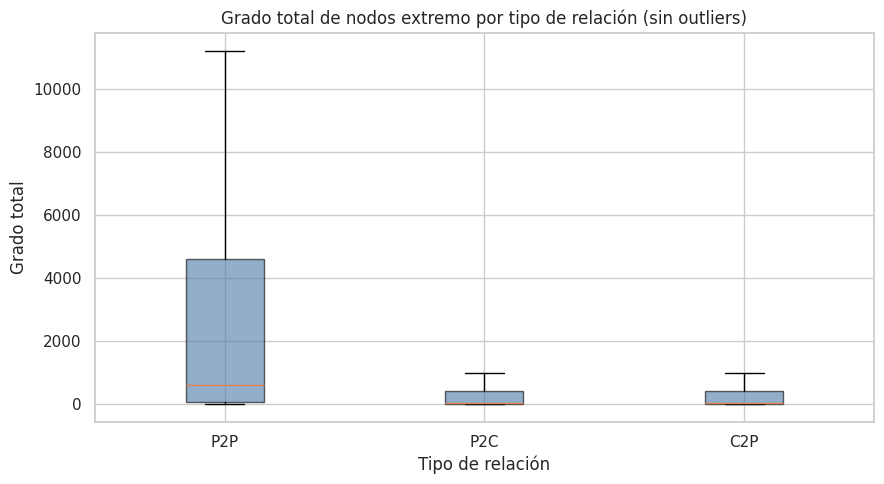


=== Mixing matrix: tipo de arista vs. relación dominante del nodo destino ===
Filas = tipo de arista, columnas = relación dominante de entrada del nodo destino


dst_main_rel,C2P,P2C,P2P
relationship,,,
C2P,0.760,0.068,0.172
P2C,0.036,0.763,0.201
P2P,0.018,0.072,0.910


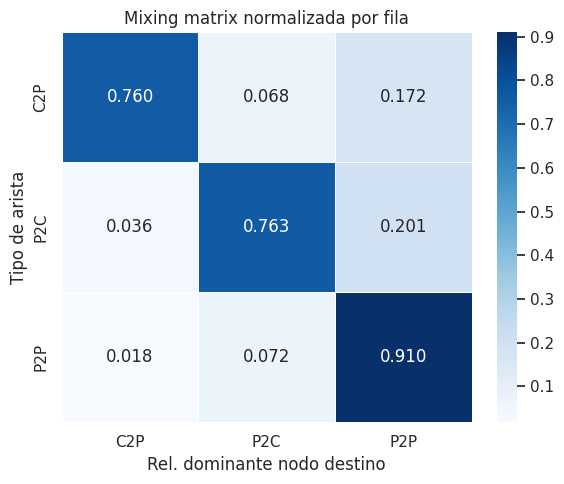


Proporción media de tipos de arista saliente por nodo (diversidad de vecindad):


,P2P,P2C,C2P
promedio,0.1129,0.8276,0.0595


In [ ]:
if df_edges is not None and df_nodes is not None:
    rel_col = next((c for c in ["label", "relationship", "Relationship"] if c in df_edges.columns), None)
    label_names = {-1: "Unknown", 0: "P2P", 1: "P2C", 2: "C2P"}

    # Node degree
    degree_out = df_edges["src_id"].value_counts().rename("out_degree")
    degree_in = df_edges["dst_id"].value_counts().rename("in_degree")
    degree_df = pd.concat([degree_out, degree_in], axis=1).fillna(0).astype(int)
    degree_df["total_degree"] = degree_df["out_degree"] + degree_df["in_degree"]

    if rel_col:
        labeled_edges = df_edges[df_edges[rel_col] != -1].copy()

        # Degree distribution by relationship type across edge endpoints
        rows_src = labeled_edges[["src_id", rel_col]].rename(columns={"src_id": "node_id"})
        rows_dst = labeled_edges[["dst_id", rel_col]].rename(columns={"dst_id": "node_id"})
        endpoints = pd.concat([rows_src, rows_dst]).join(degree_df["total_degree"], on="node_id")

        print("=== Total degree distribution by relationship type (edge endpoints) ===")
        stats_cls = endpoints.groupby(rel_col)["total_degree"].describe().round(2)
        stats_cls.index = stats_cls.index.map(label_names)
        display(stats_cls)

        # Degree boxplot by class
        fig, ax = plt.subplots(figsize=(9, 5))
        data_plot = [
            endpoints[endpoints[rel_col] == cls]["total_degree"].values
            for cls in sorted(label_names) if cls != -1
        ]
        labels_plot = [label_names[c] for c in sorted(label_names) if c != -1]
        ax.boxplot(
            data_plot,
            labels=labels_plot,
            showfliers=False,
            patch_artist=True,
            boxprops=dict(facecolor="#4C78A8", alpha=0.6),
        )
        ax.set_title("Total degree of endpoint nodes by relationship type (without outliers)")
        ax.set_xlabel("Relationship type")
        ax.set_ylabel("Total degree")
        plt.tight_layout()
        plt.show()

        # --- Mixing matrix ---
        print("\n=== Mixing matrix: edge type vs. dominant incoming relationship of destination node ===")
        dst_main = (
            labeled_edges.groupby("dst_id")[rel_col]
            .apply(lambda x: x.value_counts().idxmax())
            .rename("dst_main_rel")
        )
        ea = labeled_edges.join(dst_main, on="dst_id")
        mixing = pd.crosstab(
            ea[rel_col].map(label_names),
            ea["dst_main_rel"].map(label_names),
            normalize="index",
        ).round(3)

        print("Rows = edge type, columns = dominant incoming relationship at destination node")
        display(mixing)

        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(mixing, annot=True, fmt=".3f", cmap="Blues", ax=ax, linewidths=0.5)
        ax.set_title("Row-normalized mixing matrix")
        ax.set_xlabel("Dominant destination-node relationship")
        ax.set_ylabel("Edge type")
        plt.tight_layout()
        plt.show()

        # Mean proportion of outgoing edge types per node
        src_rel = labeled_edges.groupby(["src_id", rel_col]).size().unstack(fill_value=0)
        src_rel.columns = [label_names.get(c, str(c)) for c in src_rel.columns]
        src_rel_pct = src_rel.div(src_rel.sum(axis=1), axis=0)
        print("\nMean proportion of outgoing edge types per node (neighborhood diversity):")
        display(src_rel_pct.mean().to_frame("mean").T.round(4))
else:
    print("No data loaded.")

## 7) Conclusiones rápidas

Usa este checklist antes de entrenar:
- [ ] No hay columnas clave faltantes (`node_id`, `src_id`, `dst_id`)
- [ ] Duplicados/self-loops controlados
- [ ] Distribución de clases conocida (para elegir estrategia de balanceo)
- [ ] Coherencia de pares no dirigidos revisada

## 8) Tabla comparativa entre RIBs extraídas en distintos tiempos

Esta sección compara automáticamente los archivos:

- `rib_20260301_0000_to_20260301_0100.txt`
- `rib_20260301_0000_to_20260301_0200.txt`
- `rib_20260301_0000_to_20260301_0400.txt`
- `rib_20260301_0000_to_20260301_0600.txt`
- `rib_20260301_0000_to_20260301_1200.txt`
- `rib_20260301_0000_to_20260302_0000.txt`

Métricas reportadas por archivo:
- existencia y tamaño
- total de líneas
- líneas no vacías y comentarios
- líneas únicas
- estimación de ASNs únicos detectados en texto

In [ ]:
import re
from time import perf_counter

rib_dir = data_path
rib_files = [
    "rib_20260301_0000_to_20260301_0100.txt",
    "rib_20260301_0000_to_20260301_0200.txt",
    "rib_20260301_0000_to_20260301_0400.txt",
    "rib_20260301_0000_to_20260301_0600.txt",
    "rib_20260301_0000_to_20260301_1200.txt",
    "rib_20260301_0000_to_20260302_0000.txt",
]

# Lectura completa (sin máximo de líneas)
MAX_LINES = None

asn_token_re = re.compile(r"^\d+$")


def extract_as_path_tokens(line: str) -> list[int]:
    """
    Extrae la secuencia de ASNs desde una línea de RIB.
    Formato detectado en tus archivos: ASN|ASN|ASN... (sin metadata adicional).
    """
    s = line.strip()
    if not s or s.startswith("#"):
        return []

    # Caso principal: secuencia delimitada por '|'
    if "|" in s:
        tokens = [t.strip() for t in s.split("|") if t.strip()]
        asns = [int(t) for t in tokens if asn_token_re.match(t)]
        return asns

    # Fallback: línea con ASN(s) separados por espacios
    tokens = s.split()
    asns = [int(t) for t in tokens if asn_token_re.match(t)]
    return asns


rows = []
all_asns_cumulative = set()
all_asns_intersection = None  # intersección entre archivos procesados

all_edges_cumulative = set()  # aristas dirigidas (u,v)
all_edges_intersection = None

for fname in rib_files:
    fpath = rib_dir / fname
    t0 = perf_counter()

    info = {
        "archivo": fname,
        "existe": fpath.exists(),
        "error_lectura": "",
        "tamano_mb": np.nan,
        "lineas_total": np.nan,
        "lineas_no_vacias": np.nan,
        "lineas_comentario": np.nan,
        "as_paths_total": np.nan,
        "as_paths_unicos": np.nan,
        "asns_unicos_archivo": np.nan,
        "asns_superpuestos_previos": np.nan,
        "asns_nuevos_agregados": np.nan,
        "asns_interseccion_acumulada": np.nan,
        "edges_total_observados": np.nan,
        "edges_unicos_archivo": np.nan,
        "edges_superpuestos_previos": np.nan,
        "edges_nuevos_agregados": np.nan,
        "edges_interseccion_acumulada": np.nan,
        "tiempo_s": np.nan,
    }

    if fpath.exists():
        lineas_total = 0
        lineas_no_vacias = 0
        lineas_comentario = 0

        as_paths_total = 0
        as_paths_set = set()
        asns_file = set()

        edges_total_obs = 0
        edges_file = set()

        try:
            with open(fpath, "r", encoding="utf-8", errors="ignore") as f:
                for line in f:
                    lineas_total += 1
                    if MAX_LINES is not None and lineas_total > MAX_LINES:
                        break

                    s = line.strip()
                    if not s:
                        continue

                    lineas_no_vacias += 1
                    if s.startswith("#"):
                        lineas_comentario += 1
                        continue

                    path_asns = extract_as_path_tokens(s)
                    if not path_asns:
                        continue

                    as_paths_total += 1
                    as_paths_set.add("|".join(str(a) for a in path_asns))
                    asns_file.update(path_asns)

                    if len(path_asns) >= 2:
                        path_edges = list(zip(path_asns[:-1], path_asns[1:]))
                        edges_total_obs += len(path_edges)
                        edges_file.update(path_edges)

            # Métricas ASN incremental
            superpuestos = len(asns_file & all_asns_cumulative)
            nuevos = len(asns_file - all_asns_cumulative)
            all_asns_cumulative |= asns_file

            if all_asns_intersection is None:
                all_asns_intersection = set(asns_file)
            else:
                all_asns_intersection &= asns_file

            # Métricas aristas incremental
            edges_superpuestos = len(edges_file & all_edges_cumulative)
            edges_nuevos = len(edges_file - all_edges_cumulative)
            all_edges_cumulative |= edges_file

            if all_edges_intersection is None:
                all_edges_intersection = set(edges_file)
            else:
                all_edges_intersection &= edges_file

            info.update({
                "tamano_mb": round(fpath.stat().st_size / (1024 * 1024), 3),
                "lineas_total": lineas_total,
                "lineas_no_vacias": lineas_no_vacias,
                "lineas_comentario": lineas_comentario,
                "as_paths_total": as_paths_total,
                "as_paths_unicos": len(as_paths_set),
                "asns_unicos_archivo": len(asns_file),
                "asns_superpuestos_previos": superpuestos,
                "asns_nuevos_agregados": nuevos,
                "asns_interseccion_acumulada": len(all_asns_intersection),
                "edges_total_observados": edges_total_obs,
                "edges_unicos_archivo": len(edges_file),
                "edges_superpuestos_previos": edges_superpuestos,
                "edges_nuevos_agregados": edges_nuevos,
                "edges_interseccion_acumulada": len(all_edges_intersection),
                "tiempo_s": round(perf_counter() - t0, 3),
            })
        except OSError as e:
            info["error_lectura"] = f"{type(e).__name__}: {e}"
            info["tiempo_s"] = round(perf_counter() - t0, 3)

    rows.append(info)

cmp_df = pd.DataFrame(rows)
cmp_df["orden"] = range(1, len(cmp_df) + 1)
cmp_df = cmp_df.sort_values("orden").drop(columns=["orden"])

display(cmp_df)

resumen_cols = [
    "archivo",
    "as_paths_total",
    "as_paths_unicos",
    "asns_unicos_archivo",
    "asns_superpuestos_previos",
    "asns_nuevos_agregados",
    "asns_interseccion_acumulada",
    "edges_unicos_archivo",
    "edges_superpuestos_previos",
    "edges_nuevos_agregados",
    "edges_interseccion_acumulada",
]
print("\nResumen de AS_PATH / ASN / EDGES por archivo:")
display(cmp_df[resumen_cols])

# Mostrar advertencias de lectura, si existen
errors_df = cmp_df[cmp_df["error_lectura"].astype(str).str.len() > 0][["archivo", "error_lectura"]]
if not errors_df.empty:
    print("\n[Advertencia] Se detectaron errores de lectura en algunos archivos:")
    display(errors_df)

plot_df = cmp_df[(cmp_df["existe"] == True) & (cmp_df["error_lectura"].astype(str).str.len() == 0)].copy()
if not plot_df.empty:
    plt.figure(figsize=(11, 4))
    ax = sns.barplot(data=plot_df, x="archivo", y="as_paths_total", color="teal")
    ax.set_title("Cantidad de AS_PATH por archivo RIB")
    ax.set_xlabel("Archivo")
    ax.set_ylabel("AS_PATH totales")
    plt.xticks(rotation=30, ha="right")
    for i, val in enumerate(plot_df["as_paths_total"].fillna(0).astype(int).tolist()):
        ax.text(i, val, f"{val:,}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(11, 4))
    ax = sns.barplot(data=plot_df, x="archivo", y="asns_nuevos_agregados", color="darkorange")
    ax.set_title("ASNs nuevos agregados por archivo (vs acumulado previo)")
    ax.set_xlabel("Archivo")
    ax.set_ylabel("ASNs nuevos")
    plt.xticks(rotation=30, ha="right")
    for i, val in enumerate(plot_df["asns_nuevos_agregados"].fillna(0).astype(int).tolist()):
        ax.text(i, val, f"{val:,}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(11, 4))
    ax = sns.barplot(data=plot_df, x="archivo", y="edges_nuevos_agregados", color="mediumpurple")
    ax.set_title("Aristas dirigidas nuevas por archivo (vs acumulado previo)")
    ax.set_xlabel("Archivo")
    ax.set_ylabel("Aristas nuevas")
    plt.xticks(rotation=30, ha="right")
    for i, val in enumerate(plot_df["edges_nuevos_agregados"].fillna(0).astype(int).tolist()):
        ax.text(i, val, f"{val:,}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No hay archivos legibles para comparar en la ruta configurada.")

print("\n[Modo] Lectura completa habilitada: se procesa cada archivo entero (sin límite de líneas).")

In [ ]:
# Diagnóstico de formato real de líneas RIB (primeras líneas no vacías)
from itertools import islice

sample_file = rib_dir / rib_files[0]
print(f"Archivo de muestra: {sample_file}")

if sample_file.exists():
    with open(sample_file, "r", encoding="utf-8", errors="ignore") as f:
        shown = 0
        for line in f:
            s = line.strip()
            if not s:
                continue
            print("-" * 80)
            print(s[:500])
            if "|" in s:
                parts = s.split("|")
                print(f"Campos por '|': {len(parts)}")
                print("Primeros campos:", [p[:60] for p in parts[:8]])
            shown += 1
            if shown >= 5:
                break
else:
    print("No existe el archivo de muestra.")

Archivo de muestra: /media/vale/KINGSTON/TESIS/data_2026/rib_20260301_0000_to_20260301_0100.txt
--------------------------------------------------------------------------------
13335
--------------------------------------------------------------------------------
6939|38040|38040|38040|38040|23969
Campos por '|': 6
Primeros campos: ['6939', '38040', '38040', '38040', '38040', '23969']
--------------------------------------------------------------------------------
6939|4651|4651|23969
Campos por '|': 4
Primeros campos: ['6939', '4651', '4651', '23969']
--------------------------------------------------------------------------------
6939|4651|4651|23969|23969
Campos por '|': 5
Primeros campos: ['6939', '4651', '4651', '23969', '23969']
--------------------------------------------------------------------------------
6939|4651|4651|23969|23974
Campos por '|': 5
Primeros campos: ['6939', '4651', '4651', '23969', '23974']
